# ConvRNN dynamic dRSA against neural AIT

Visualizes `dynamic_dRSA_*rgc_intermediate_conv10*.npz` files saved under the configured IT_recap results folder.

In [1]:
import os
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml


ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')


@dataclass
class Cfg:
    env: str = ENV
    result_pattern: str = 'dynamic_dRSA_cosine_cnt-cosine_cnt_three0_250313_AIT_rgc_intermediate_conv10_100Hz_spearman.npz'
    cmap: str = 'magma'
    save_figures: bool = True
    figure_dpi: int = 180


cfg = Cfg()
cfg


Cfg(env='tiziano_mac_mini', result_pattern='dynamic_dRSA_cosine_cnt-cosine_cnt_three0_250313_AIT_rgc_intermediate_conv10_100Hz_spearman.npz', cmap='magma', save_figures=True, figure_dpi=180)

In [2]:
"""
find_project_root
Find the project folder containing config.yaml.

INPUT:
    - start_path: Path -> folder used to start the upward search

OUTPUT:
    - project_root: Path -> project folder
"""
def find_project_root(start_path=Path.cwd()):
    start_path = start_path.resolve()
    search_paths = [start_path] + list(start_path.parents)
    for path in search_paths:
        if (path / 'config.yaml').exists():
            return path
        # end if (path / 'config.yaml').exists():
    # end for path in search_paths:
    fallback = Path.home() / 'Desktop' / 'IT_recap'
    if (fallback / 'config.yaml').exists():
        return fallback
    # end if (fallback / 'config.yaml').exists():
    raise FileNotFoundError('Could not find IT_recap/config.yaml')
# EOF


"""
load_paths
Load path settings for the active environment.

INPUT:
    - project_root: Path -> project folder
    - env: str -> config environment name

OUTPUT:
    - paths: dict -> path settings from config.yaml
"""
def load_paths(project_root, env):
    with open(project_root / 'config.yaml', 'r') as f:
        config = yaml.safe_load(f)
    # end with open(project_root / 'config.yaml', 'r') as f:
    if env not in config:
        raise KeyError(f'{env} is not defined in config.yaml')
    # end if env not in config:
    return config[env]['paths']
# EOF


"""
find_result_file
Find the dynamic dRSA result file to visualize.

INPUT:
    - cfg: Cfg -> notebook configuration
    - results_dir: Path -> folder containing saved dRSA results

OUTPUT:
    - result_path: Path -> selected result file
"""
def find_result_file(cfg, results_dir):
    result_files = sorted(results_dir.glob(cfg.result_pattern))
    if len(result_files) == 0:
        raise FileNotFoundError(
            f'No result files matching {cfg.result_pattern} in {results_dir}'
        )
    # end if len(result_files) == 0:
    return result_files[-1]
# EOF


PROJECT_ROOT = find_project_root()
paths = load_paths(PROJECT_ROOT, cfg.env)
data_path = Path(paths.get('it_recap_data_path', paths['data_path']))
RESULTS_DIR = data_path / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
RESULT_PATH = find_result_file(cfg, RESULTS_DIR)

print('result:', RESULT_PATH)


result: /Users/tizianocausin/IT_recap_local/results/dynamic_dRSA_cosine_cnt-cosine_cnt_three0_250313_AIT_rgc_intermediate_conv10_100Hz_spearman.npz


In [3]:
"""
load_dynamic_drsa_result
Load neural-RNN dynamic dRSA arrays.

INPUT:
    - result_path: Path -> .npz result file

OUTPUT:
    - drsa: np.ndarray -> neural_time x model_time RSA matrix
    - neural_times_ms: np.ndarray -> neural time axis in ms
    - model_times_ms: np.ndarray -> ConvRNN model time axis in ms
    - best_model_time_ms: np.ndarray -> best ConvRNN time for each neural time
"""
def load_dynamic_drsa_result(result_path):
    with np.load(result_path, allow_pickle=True) as data:
        drsa = data['drsa']
        neural_times_ms = data['neural_times_ms']
        model_times_ms = data['model_times_ms']
        best_model_time_ms = data['best_model_time_ms']
    # end with np.load(result_path, allow_pickle=True) as data:
    if drsa.shape != (len(neural_times_ms), len(model_times_ms)):
        raise ValueError(f'dRSA shape {drsa.shape} does not match time axes')
    # end if drsa.shape != (len(neural_times_ms), len(model_times_ms)):
    return drsa, neural_times_ms, model_times_ms, best_model_time_ms
# EOF


drsa, neural_times_ms, model_times_ms, best_model_time_ms = load_dynamic_drsa_result(
    RESULT_PATH
)

print('dRSA shape:', drsa.shape)
print('dRSA min/max:', np.nanmin(drsa), np.nanmax(drsa))


dRSA shape: (30, 16)
dRSA min/max: -0.0026717503 0.16381915


In [4]:
"""
save_figure
Save a Matplotlib figure when requested by the notebook config.

INPUT:
    - fig: matplotlib.figure.Figure -> figure to save
    - figures_dir: Path -> output folder for figure files
    - result_path: Path -> result file used to build the figure
    - suffix: str -> figure-specific filename suffix
    - cfg: Cfg -> notebook configuration

OUTPUT:
    - figure_path: Path | None -> saved figure path, or None if saving is disabled
"""
def save_figure(fig, figures_dir, result_path, suffix, cfg):
    if not cfg.save_figures:
        return None
    # end if not cfg.save_figures:
    figures_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figures_dir / f'{result_path.stem}_{suffix}.png'
    fig.savefig(figure_path, dpi=cfg.figure_dpi, bbox_inches='tight')
    print('saved:', figure_path)
    return figure_path
# EOF


saved: /Users/tizianocausin/IT_recap_local/results/figures/dynamic_dRSA_cosine_cnt-cosine_cnt_three0_250313_AIT_rgc_intermediate_conv10_100Hz_spearman_heatmap.png


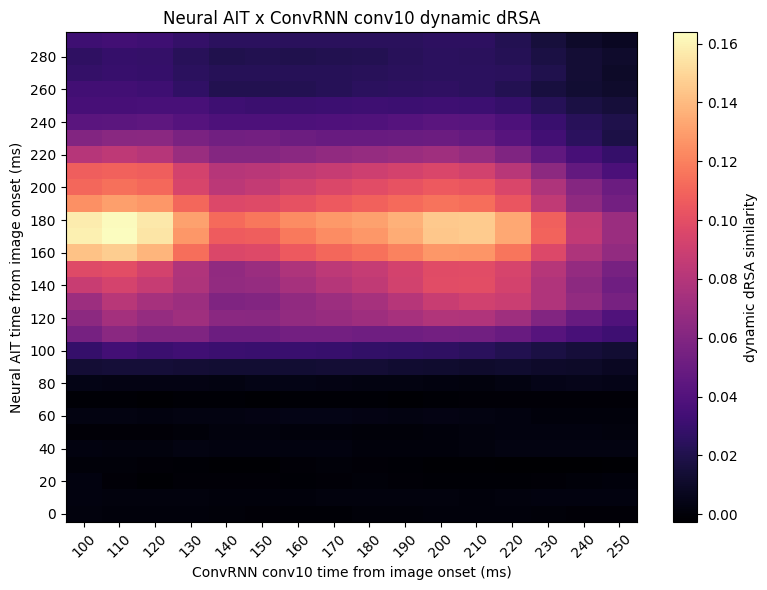

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(drsa, aspect='auto', origin='lower', cmap=cfg.cmap)
ax.set_xlabel('ConvRNN conv10 time from image onset (ms)')
ax.set_ylabel('Neural AIT time from image onset (ms)')
ax.set_xticks(np.arange(len(model_times_ms)))
ax.set_xticklabels(model_times_ms.astype(int), rotation=45)
ax.set_yticks(np.arange(0, len(neural_times_ms), 2))
ax.set_yticklabels(neural_times_ms[::2].astype(int))
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('dynamic dRSA similarity')
ax.set_title('Neural AIT x ConvRNN conv10 dynamic dRSA')
fig.tight_layout()
HEATMAP_PATH = save_figure(fig, FIGURES_DIR, RESULT_PATH, 'heatmap', cfg)


saved: /Users/tizianocausin/IT_recap_local/results/figures/dynamic_dRSA_cosine_cnt-cosine_cnt_three0_250313_AIT_rgc_intermediate_conv10_100Hz_spearman_best_model_time.png


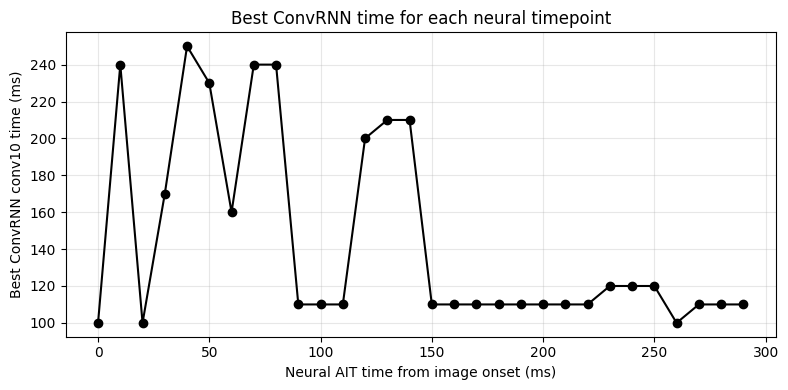

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(neural_times_ms, best_model_time_ms, marker='o', color='black')
ax.set_xlabel('Neural AIT time from image onset (ms)')
ax.set_ylabel('Best ConvRNN conv10 time (ms)')
ax.set_title('Best ConvRNN time for each neural timepoint')
ax.grid(True, alpha=0.3)
fig.tight_layout()
BEST_TIME_PATH = save_figure(fig, FIGURES_DIR, RESULT_PATH, 'best_model_time', cfg)
